In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [2]:
data = [
    {"Age": 22, "Salary": 25000, "BuysCar": "No"},
    {"Age": 25, "Salary": 30000, "BuysCar": "No"},
    {"Age": 28, "Salary": 35000, "BuysCar": "Yes"},
    {"Age": 35, "Salary": 40000, "BuysCar": "Yes"},
    {"Age": 40, "Salary": 45000, "BuysCar": "Yes"},
    {"Age": 30, "Salary": 50000, "BuysCar": "Yes"},
    {"Age": 45, "Salary": 60000, "BuysCar": "Yes"},
    {"Age": 23, "Salary": 20000, "BuysCar": "No"},
    {"Age": 38, "Salary": 52000, "BuysCar": "Yes"},
    {"Age": 27, "Salary": 28000, "BuysCar": "No"}
]

df=pd.DataFrame(data)
display(df.head())


,Age,Salary,BuysCar
0,22,25000,No
1,25,30000,No
2,28,35000,Yes
3,35,40000,Yes
4,40,45000,Yes


In [3]:
from sklearn.model_selection import train_test_split,GridSearchCV

In [5]:
x=df[["Age","Salary"]]
target=df["BuysCar"]
xtrain,xtest,ytrain,ytest=train_test_split(x,target,test_size=0.2,random_state=42)

In [6]:
model=RandomForestClassifier(n_jobs=-1,random_state=42)

In [7]:
params={"max_depth":[2,3,5,10,20],"min_samples_leaf":[10,20,30,40,50],"n_estimators":[10,20,30,50,100]}

In [8]:
gs=GridSearchCV(estimator=model,param_grid=params,n_jobs=-1,scoring="accuracy")

In [9]:
gs.fit(xtrain,ytrain)

C:\Python312\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


GridSearchCV(estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [10, 20, 30, 40, 50],
                         'n_estimators': [10, 20, 30, 50, 100]},
             scoring='accuracy')

In [10]:
gs.best_score_

0.7

In [11]:
model=gs.best_estimator_

In [12]:
model

RandomForestClassifier(max_depth=2, min_samples_leaf=10, n_estimators=10,
                       n_jobs=-1, random_state=42)

In [19]:
model.estimators_

[DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=1608637542),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=1273642419),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=1935803228),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=787846414),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=996406378),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=1201263687),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                        random_state=423734972),
 DecisionTreeClassifier(max_depth=2, max_features='sqrt', min_samples_leaf=10,
                     

In [13]:
from sklearn.tree import plot_tree

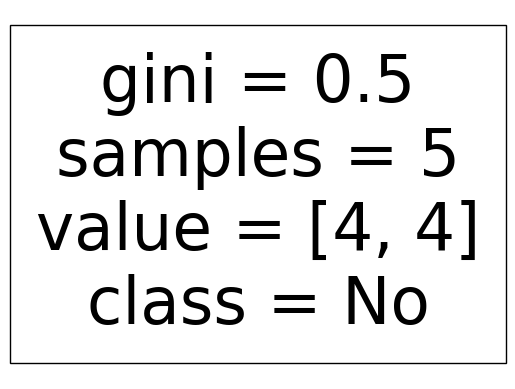

In [21]:
plot_tree(model.estimators_[5],class_names=["No","Yes"],filled=True,feature_names=x.columns)
plt.show()